# Лабораторная работа 9
- Реализовать YOLO модель
- Обучить и предсказать brain tumor
- реализовать NMS

In [1]:
!gdown 1LXVS242mUFDg3gQLlSv4Qmi_0B6fiL68
!unzip -q "/content/brain-tumor.zip"

Downloading...
From: https://drive.google.com/uc?id=1LXVS242mUFDg3gQLlSv4Qmi_0B6fiL68
To: /content/brain-tumor.zip
100% 4.42M/4.42M [00:00<00:00, 42.8MB/s]


In [2]:
train_img = "/content/images/train"
train_labels = "/content/labels/train"

test_img = "/content/images/val"
test_labels = "/content/labels/val"

In [3]:
import os
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T
import torch

class YOLOFolderDataset(Dataset):
    def __init__(self, img_dir, lbl_dir, img_size=224):
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.img_files = sorted(os.listdir(img_dir))

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
      return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        label_name = img_name.rsplit(".", 1)[0] + ".txt"
        label_path = os.path.join(self.lbl_dir, label_name)

        targets = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, xc, yc, w, h = map(float, line.strip().split())
                    targets.append([xc, yc, w, h, 1.0, cls])

        if len(targets) == 0:
            targets = torch.zeros((0, 6))
        else:
            targets = torch.tensor(targets)

        return img, targets


In [4]:
def collate_fn(batch):
    imgs, targets = zip(*batch)
    imgs = torch.stack(imgs)
    return imgs, targets

In [5]:
from torch.utils.data import DataLoader

train_ds = YOLOFolderDataset(train_img, train_labels)
val_ds   = YOLOFolderDataset(test_img, test_labels)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,
                          num_workers=2, collate_fn=collate_fn)

val_loader = DataLoader(val_ds, batch_size=4, shuffle=False,
                        num_workers=2, collate_fn=collate_fn)

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision

In [7]:
class_names = {0: "Negative", 1: "Positive"}

def visualize_sample(img_tensor, targets, class_names=class_names):

    img = img_tensor.clone().cpu()
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img = img.clamp(0, 1)
    img = img.permute(1,2,0).numpy()

    fig, ax = plt.subplots(1, figsize=(6,6))
    ax.imshow(img)

    H, W = img.shape[:2]

    for t in targets:
        xc, yc, w, h, conf, cls = t
        x1 = (xc - w/2) * W
        y1 = (yc - h/2) * H
        width = w * W
        height = h * H

        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, class_names[int(cls)], color='yellow', fontsize=12, weight='bold')

    plt.axis('off')
    plt.show()



In [8]:
tmp = iter(train_loader)

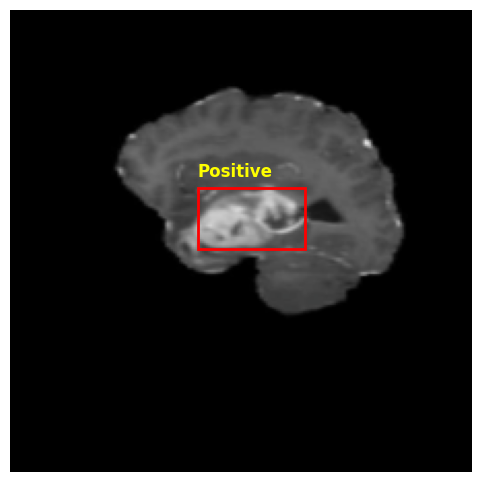

In [11]:
images, targets = next(tmp)
visualize_sample(images[0], targets[0])

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [13]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b7

# YOLO модель

В качесте backbone взят efficientnet_b7

In [20]:
NUM_CLASSES = 2
BBOX_ATTRS = 5
GRID_SIZE = 7

B = 3

class SimpleYOLO(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, grid_size=GRID_SIZE):
        super(SimpleYOLO, self).__init__()
        self.grid_size = grid_size
        self.num_classes = num_classes

        backbone = efficientnet_b7(pretrained=True)
        self.feature_extractor = backbone.features
        self.conv1 = nn.Conv2d(2560, 512, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(512)
        self.conv2 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(256)
        self.pred_conv = nn.Conv2d(256, B*(BBOX_ATTRS + num_classes), kernel_size=1)

    def forward(self, x):
        batch_size = x.size(0)
        x = self.feature_extractor(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pred_conv(x)
        x = F.interpolate(x, size=(self.grid_size, self.grid_size))
        x = x.permute(0,2,3,1)
        x = x.view(
          batch_size,
          self.grid_size,
          self.grid_size,
          B,
          BBOX_ATTRS + self.num_classes
      )
        return x

# Комбинированная функция потерь

In [21]:
class YoloLoss(nn.Module):
    def __init__(self, S=GRID_SIZE, B=1, C=NUM_CLASSES):
        super(YoloLoss, self).__init__()
        self.S = S
        self.B = B
        self.C = C
        self.mse = nn.MSELoss(reduction='sum')

    def forward(self, predictions, target):
        pred_box = predictions[..., :4]
        pred_conf = predictions[..., 4]
        pred_cls = predictions[..., 5:]

        target_box = target[..., :4]
        target_conf = target[..., 4]
        target_cls = target[..., 5:]

        coord_loss = self.mse(pred_box * target_conf.unsqueeze(-1), target_box * target_conf.unsqueeze(-1))
        conf_loss = self.mse(pred_conf, target_conf)
        class_loss = self.mse(pred_cls * target_conf.unsqueeze(-1), target_cls * target_conf.unsqueeze(-1))

        total_loss = coord_loss + conf_loss + class_loss
        return total_loss

# NMS

In [27]:
import torch
from torchvision.ops import nms

def non_max_suppression(pred, conf_thresh=0.5, iou_thresh=0.5, img_size=224):
    S = pred.shape[0]
    B = pred.shape[2]
    boxes, scores, class_ids = [], [], []

    cell_size = img_size / S

    for i in range(S):
        for j in range(S):
            for b in range(B):
                x, y, w, h, conf = pred[i, j, b, :5]
                class_scores = pred[i, j, b, 5:]
                class_id = torch.argmax(class_scores).item()
                score = conf * class_scores[class_id]

                if score < conf_thresh:
                    continue

                cx = (j + x) * cell_size
                cy = (i + y) * cell_size
                bw = w * img_size
                bh = h * img_size
                x1 = cx - bw / 2
                y1 = cy - bh / 2
                x2 = cx + bw / 2
                y2 = cy + bh / 2

                boxes.append([x1, y1, x2, y2])
                scores.append(score)
                class_ids.append(class_id)

    if len(boxes) == 0:
        return []

    boxes = torch.tensor(boxes, device=pred.device)
    scores = torch.tensor(scores, device=pred.device)
    class_ids = torch.tensor(class_ids, device=pred.device)

    final_boxes = []
    for cls in class_ids.unique():
        idxs = (class_ids == cls).nonzero(as_tuple=True)[0]
        keep = nms(boxes[idxs], scores[idxs], iou_thresh)
        for k in keep:
            final_boxes.append([
                boxes[idxs[k]][0].item(),
                boxes[idxs[k]][1].item(),
                boxes[idxs[k]][2].item(),
                boxes[idxs[k]][3].item(),
                scores[idxs[k]].item(),
                cls.item()
            ])

    return final_boxes


In [22]:
import torch.optim as optim
from tqdm import tqdm

In [23]:
model = SimpleYOLO().to(device)
criterion = YoloLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
num_epochs = 10

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [25]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]")

    for imgs, targets in loop:
        imgs = imgs.to(device)
        batch_targets = torch.zeros((imgs.size(0), GRID_SIZE, GRID_SIZE, B, BBOX_ATTRS + NUM_CLASSES), device=device)
        for i, t in enumerate(targets):
            if t.shape[0] == 0:
                continue
            for obj in t:
                xc, yc, w, h, conf, cls = obj
                grid_x = min(int(xc * GRID_SIZE), GRID_SIZE-1)
                grid_y = min(int(yc * GRID_SIZE), GRID_SIZE-1)
                batch_targets[i, grid_y, grid_x, 0, :4] = torch.tensor([xc, yc, w, h], device=device)
                batch_targets[i, grid_y, grid_x, 0, 4] = 1.0
                batch_targets[i, grid_y, grid_x, 0, 5 + int(cls)] = 1.0

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, batch_targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        loop.set_postfix(loss=train_loss/(loop.n+1))

    scheduler.step()

Epoch 10/10 [TRAIN]: 100%|██████████| 224/224 [00:47<00:00,  4.71it/s, loss=0.38]


In [28]:
model.eval()
val_loss = 0.0
with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = imgs.to(device)

        batch_targets = torch.zeros((imgs.size(0), GRID_SIZE, GRID_SIZE, B, BBOX_ATTRS + NUM_CLASSES), device=device)
        for i, t in enumerate(targets):
            if t.shape[0] == 0:
                continue
            for obj in t:
                xc, yc, w, h, conf, cls = obj
                grid_x = min(int(xc * GRID_SIZE), GRID_SIZE-1)
                grid_y = min(int(yc * GRID_SIZE), GRID_SIZE-1)
                batch_targets[i, grid_y, grid_x, 0, :4] = torch.tensor([xc, yc, w, h], device=device)
                batch_targets[i, grid_y, grid_x, 0, 4] = 1.0
                batch_targets[i, grid_y, grid_x, 0, 5 + int(cls)] = 1.0

        outputs = model(imgs)
        loss = criterion(outputs, batch_targets)
        val_loss += loss.item()

        for b in range(outputs.size(0)):
            final_boxes = non_max_suppression(outputs[b], conf_thresh=0.5, iou_thresh=0.5)

print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

Epoch [10/10] Train Loss: 0.3801 | Val Loss: 3.7885


In [61]:
names = {1: "Positive", 0: "Negative"}

In [70]:
# @title
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def visualize_val_batch(
    model, val_loader, device,
    nms_on=True, conf_thresh=0.1, iou_thresh=0.5,
    img_size=224, max_images=5
):
    anchor_colors = ['r', 'g', 'b']
    model.eval()
    images_shown = 0

    def denormalize(img, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
        img = img.cpu().clone()
        for c in range(3):
            img[c] = img[c] * std[c] + mean[c]
        return img.permute(1,2,0).numpy().clip(0,1)

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)

            for b in range(outputs.size(0)):
                img = denormalize(imgs[b])
                fig, ax = plt.subplots(1,1, figsize=(6,6))
                ax.imshow(img)

                for obj in targets[b]:
                    xc, yc, w, h, conf, cls = obj
                    cx, cy = xc * img_size, yc * img_size
                    bw, bh = w * img_size, h * img_size
                    x1, y1 = cx - bw/2, cy - bh/2

                    rect = patches.Rectangle(
                        (float(x1), float(y1)),
                        float(bw), float(bh),
                        linewidth=2,
                        edgecolor='green',
                        facecolor='green',
                        alpha=0.3
                    )
                    ax.add_patch(rect)

                if nms_on:
                    boxes = non_max_suppression(
                        outputs[b],
                        conf_thresh=conf_thresh,
                        iou_thresh=iou_thresh,
                        img_size=img_size
                    )
                    for x1, y1, x2, y2, score, cls in boxes:
                        rect = patches.Rectangle(
                            (x1, y1), x2-x1, y2-y1,
                            linewidth=2, edgecolor='red', facecolor='none'
                        )
                        ax.add_patch(rect)
                        ax.text(x1, y1-5, f"{names[cls]} {score:.2f}",
                                color='yellow', fontsize=8,
                                backgroundcolor='black')
                else:
                    S, _, B_ = outputs[b].shape[:3]
                    cell = img_size / S
                    for i in range(S):
                        for j in range(S):
                            for bb in range(B_):
                                x,y,w,h,conf = outputs[b,i,j,bb,:5]
                                cls_scores = torch.sigmoid(outputs[b,i,j,bb,5:])
                                conf = torch.sigmoid(conf)
                                cls_id = torch.argmax(cls_scores).item()
                                score = (conf * cls_scores[cls_id]).item()
                                if score < conf_thresh:
                                    continue

                                cx = (j + x) * cell
                                cy = (i + y) * cell
                                bw = w * img_size
                                bh = h * img_size
                                x1, y1 = cx - bw/2, cy - bh/2

                                rect = patches.Rectangle(
                                    (float(x1), float(y1)),
                                    float(bw), float(bh),
                                    linewidth=2,
                                    edgecolor=anchor_colors[bb],
                                    facecolor='none'
                                )
                                ax.add_patch(rect)

                plt.axis('off')
                plt.show()

                images_shown += 1
                if images_shown >= max_images:
                    return


# Зеленый - истинная разметка, красные | синие - предсказанные bbox

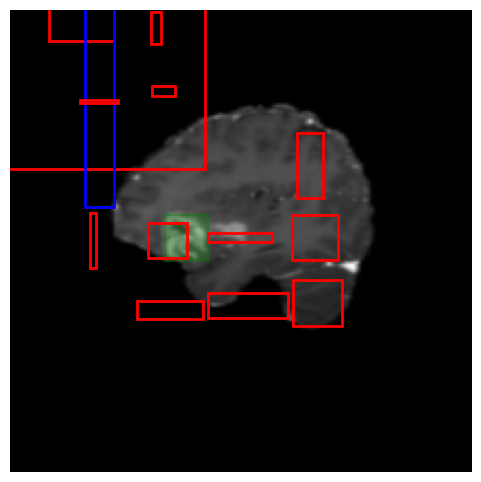

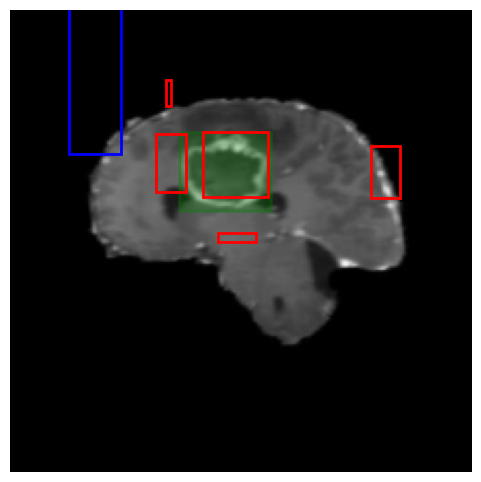

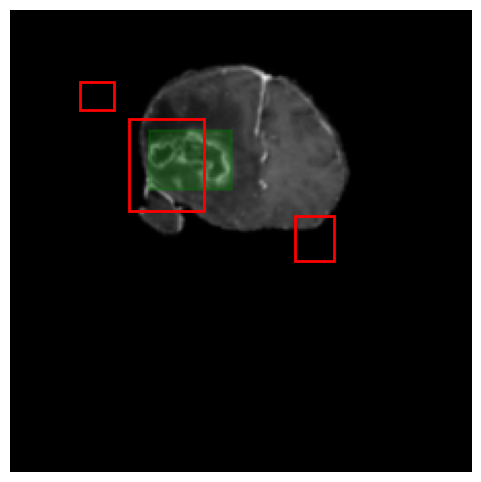

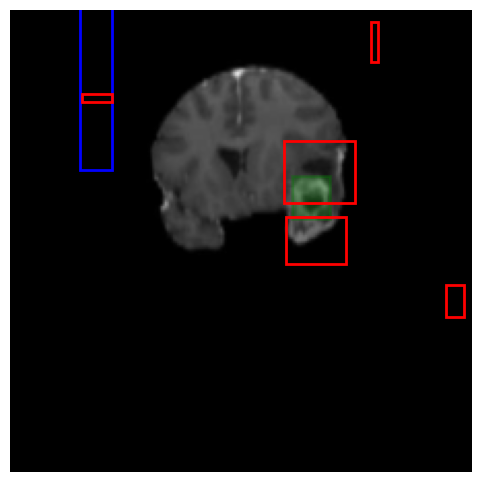

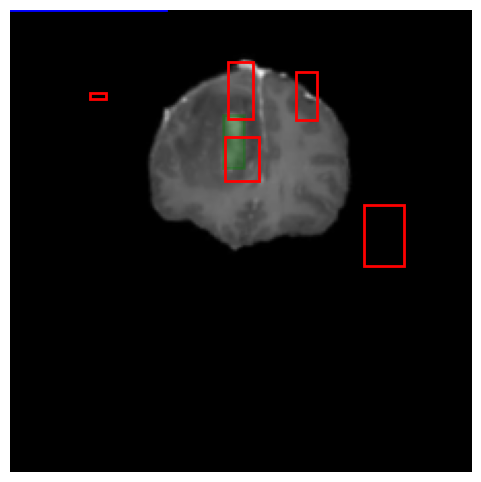

In [75]:
visualize_val_batch(model, val_loader, device, nms_on=False, conf_thresh=0.33, max_images=5)

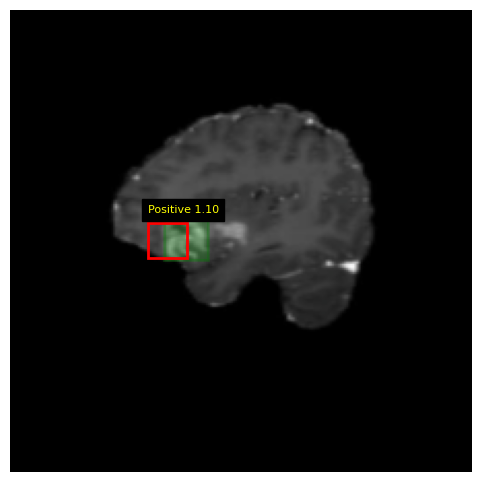

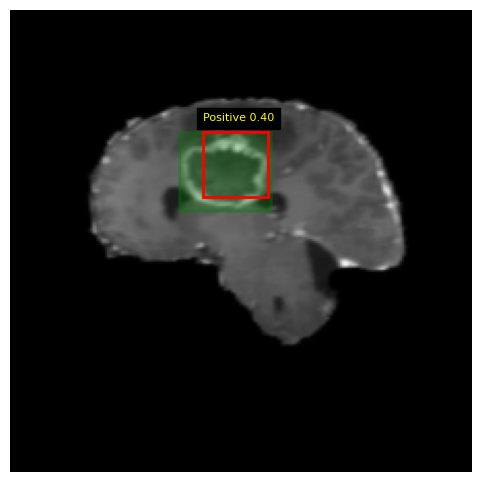

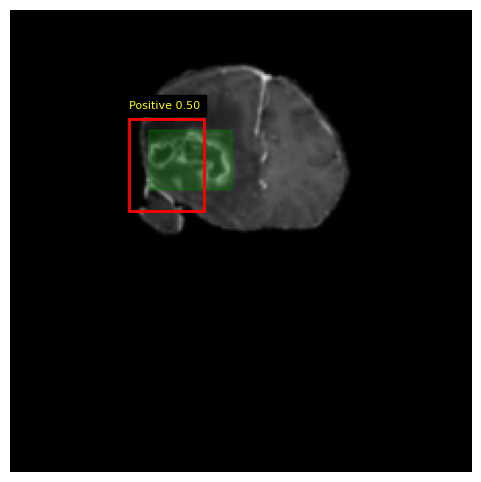

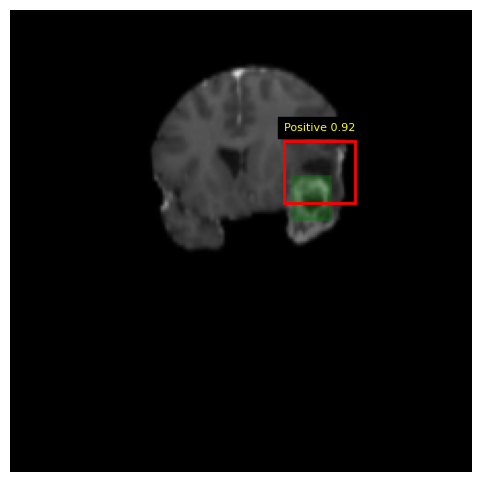

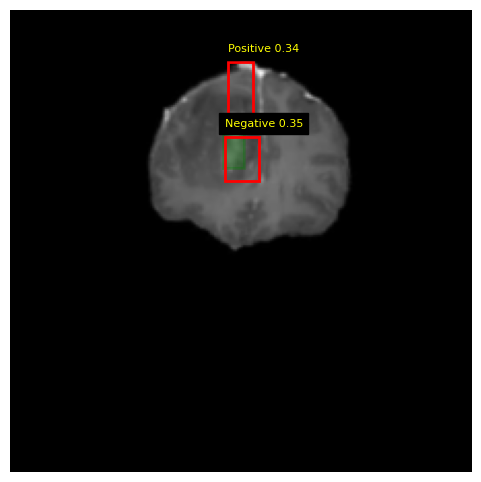

In [71]:
visualize_val_batch(model, val_loader, device, nms_on=True, conf_thresh=0.3, max_images=5)
